evaluation of different weighting schemes

In [36]:

import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# Set the path to the data directory
datapath = 'data/'


with open(f'{datapath}era5_GSAT.pkl', 'rb') as file: 
    df_era5 = pickle.load(file)

display(df_era5.head())

#just as before we will compute the baseline from 1981-2014

era5_reference=df_era5[df_era5["Year"].between(1981,2014)]["GSAT_era5"].mean()
df_era5["Anomaly"]=df_era5["GSAT_era5"]-era5_reference


# Load dataframe with cmip6 sufrace temperature data
with open(f'{datapath}cmip6_surface_temperature_5mems.pkl', 'rb') as file: 
    df_temp = pickle.load(file)


# sns.set_theme(style="whitegrid")

# DATAPATH_CANDIDATES = [
#     Path("."),
#     Path("/mnt/data/"),
# ]

# CMIP6_FILENAME = "cmip6_surface_temperature_5mems.pkl"
# ERA5_FILENAME = "era5_GSAT.pkl"

# def _find_file(filename, candidates):
#     """
#     Search for a file in a list of candidate directories.
#     """
#     for folder in candidates:
#         candidate = folder / filename
#         if candidate.exists():
#             return candidate
#     raise FileNotFoundError(
#         f"Could not find {filename}. "
#         f"Checked: {[str(c / filename) for c in candidates]}"
#     )

# if "df_temp" not in globals():
#     cmip6_path = _find_file(CMIP6_FILENAME, DATAPATH_CANDIDATES)
#     with open(cmip6_path, "rb") as f:
#         df_temp = pickle.load(f)

# # Load df_era5 if not already available
# if "df_era5" not in globals():
#     era5_path = _find_file(ERA5_FILENAME, DATAPATH_CANDIDATES)
#     with open(era5_path, "rb") as f:
#         df_era5 = pickle.load(f)

print("Loaded data:")
print("df_temp shape:", df_temp.shape)
print("df_era5 shape:", df_era5.shape)

# ERA5 data are in absolute temperature; convert to anomalies relative to 1981–2014.
# Note: anomaly in Kelvin is numerically identical to anomaly in °C.
ERA5_REF_START, ERA5_REF_END = 1981, 2014

era5_ref = df_era5[df_era5["Year"].between(ERA5_REF_START, ERA5_REF_END)]["GSAT_era5"].mean()
df_era5 = df_era5.copy()
df_era5["Anomaly"] = df_era5["GSAT_era5"] - era5_ref

# CMIP6 model anomalies:
# We first compute one reference mean per model over 1981–2014,
# then subtract it from each model run.
ref_temp_models = (
    df_temp[df_temp["Year"].between(ERA5_REF_START, ERA5_REF_END)]
    .groupby("Model")["Temperature"]
    .mean()
    .rename("ReferenceTemperature")
)

total_df = df_temp.merge(ref_temp_models, on="Model", how="left")
total_df["Anomaly"] = total_df["Temperature"] - total_df["ReferenceTemperature"]

#ensemble mean per model
# This is important: each model gets one anomaly time series.
# We do NOT weight individual ensemble members separately here,
# because that would give models with more members too much influence.
ensemble_mean = (
    total_df.groupby(["Model", "Year"], as_index=False)["Anomaly"]
    .mean()
)

print("\nCreated:")
print("- total_df with model anomalies")
print("- ensemble_mean with one anomaly trajectory per model")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def get_obs_series(df_era5, start, end):
    """
    Return observed ERA5 anomaly series indexed by year.
    """
    obs = df_era5[df_era5["Year"].between(start, end)].copy()
    return obs.set_index("Year")["Anomaly"].sort_index()

def get_model_matrix(ensemble_mean, start, end):
    """
    Return a wide matrix:
    - rows    = Year
    - columns = Model
    - values  = ensemble-mean anomaly

    This is the main object we use for weighting and plotting.
    """
    tmp = ensemble_mean[ensemble_mean["Year"].between(start, end)].copy()
    return tmp.pivot(index="Year", columns="Model", values="Anomaly").sort_index()

def weighted_series(model_matrix, weights):
    """
    Compute a weighted multi-model mean time series.

    Parameters
    ----------
    model_matrix : DataFrame
        rows = years, columns = models
    weights : Series
        index = model names, values = model weights

    Returns
    -------
    Series
        weighted anomaly time series
    """
    w = weights.reindex(model_matrix.columns)
    return model_matrix.mul(w, axis=1).sum(axis=1)

def weighted_quantile(values, quantiles, sample_weight=None):
    """
    Compute weighted quantiles.

    Useful for building likely ranges from weighted model distributions.
    """
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)

    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.asarray(sample_weight)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cum_weights = np.cumsum(sample_weight)
    cum_weights = cum_weights / cum_weights[-1]

    return np.interp(quantiles, cum_weights, values)

def compute_knutti_rmse_weights(obs_train, model_train, sigma_D=None, sigma_S=None):
    """
    Compute Knutti-style performance + independence weights:

        w_i = exp(-(D_i^2)/(sigma_D^2)) / (1 + sum_{j != i} exp(-(S_ij^2)/(sigma_S^2)))

    where:
    - D_i   = RMSE distance of model i to observations
    - S_ij  = RMSE distance between model i and model j

    Notes
    -----
    - This is a direct implementation of the RMSE-based formula
      you want to present.
    - We normalize the final weights to sum to 1.
    - If sigma_D and sigma_S are not given, we choose robust median-based scales.
    """

    # Keep only years shared by obs and models
    common_years = obs_train.index.intersection(model_train.index)
    obs = obs_train.loc[common_years]
    X = model_train.loc[common_years]

    models = X.columns

    # --------------------------------------------------------
    # 1) Performance distance D_i = RMSE(model_i, observations)
    # --------------------------------------------------------
    D_i = np.sqrt(((X.sub(obs, axis=0)) ** 2).mean(axis=0))

    if sigma_D is None:
        positive_D = D_i[D_i > 0]
        sigma_D = 0.08

    # --------------------------------------------------------
    # 2) Similarity distance S_ij = RMSE(model_i, model_j)
    # --------------------------------------------------------
    S_ij = pd.DataFrame(index=models, columns=models, dtype=float)

    for i in models:
        for j in models:
            S_ij.loc[i, j] = np.sqrt(np.mean((X[i] - X[j]) ** 2))

    offdiag = S_ij.values[np.triu_indices_from(S_ij.values, k=1)]
    offdiag = offdiag[offdiag > 0]

    if sigma_S is None:
        sigma_S = 0.31

    # --------------------------------------------------------
    # 3) Performance term in the numerator
    # --------------------------------------------------------
    performance_term = np.exp(-(D_i ** 2) / (sigma_D ** 2))

    # --------------------------------------------------------
    # 4) Independence penalty in the denominator
    # --------------------------------------------------------
    denominator = pd.Series(index=models, dtype=float)

    for i in models:
        sim_sum = 0.0
        for j in models:
            if j != i:
                sim_sum += np.exp(-(S_ij.loc[i, j] ** 2) / (sigma_S ** 2))
        denominator[i] = 1.0 + sim_sum

    # --------------------------------------------------------
    # 5) Raw weights and normalized weights
    # --------------------------------------------------------
    w_raw = performance_term / denominator
    w = w_raw / w_raw.sum()

    diagnostics = pd.DataFrame({
        "RMSE_to_obs": D_i,
        "performance_term": performance_term,
        "independence_penalty": denominator,
        "raw_weight": w_raw,
        "weight": w
    }).sort_values("weight", ascending=False)

    return w, diagnostics, S_ij, sigma_D, sigma_S

def summarize_end_of_century(future_per_model, weights, scheme_name):
    """
    Summarize a weighted end-of-century distribution:
    - weighted mean
    - weighted median
    - weighted 17th and 83rd percentiles
    """
    w = weights.reindex(future_per_model.index)
    mean_val = np.sum(w * future_per_model)
    q17, q50, q83 = weighted_quantile(future_per_model.values, [0.17, 0.50, 0.83], w.values)

    return {
        "scheme": scheme_name,
        "mean": mean_val,
        "q17": q17,
        "q50": q50,
        "q83": q83
    }

# ------------------------------------------------------------
# Default analysis periods
# ------------------------------------------------------------
CALIB_START, CALIB_END = 1940, 2024
FUTURE_START, FUTURE_END = 2071, 2100

print("\nSetup complete.")
print("Available objects:")
print("- df_temp")
print("- df_era5")
print("- total_df")
print("- ensemble_mean")
print("\nAvailable helper functions:")
print("- get_obs_series")
print("- get_model_matrix")
print("- weighted_series")
print("- weighted_quantile")
print("- compute_knutti_rmse_weights")
print("- summarize_end_of_century")

,GSAT_era5,Year
0,286.846039,1940
1,286.891022,1941
2,286.799469,1942
3,286.810059,1943
4,286.995087,1944


Loaded data:
df_temp shape: (86846, 4)
df_era5 shape: (85, 3)

Created:
- total_df with model anomalies
- ensemble_mean with one anomaly trajectory per model

Setup complete.
Available objects:
- df_temp
- df_era5
- total_df
- ensemble_mean

Available helper functions:
- get_obs_series
- get_model_matrix
- weighted_series
- weighted_quantile
- compute_knutti_rmse_weights
- summarize_end_of_century


In [37]:
obs_calib = get_obs_series(df_era5, 1940, 2024)
model_calib = get_model_matrix(ensemble_mean, 1940, 2024)

In [38]:
# ============================================================
# 1. Compute equal weights and Knutti weights
# ============================================================

# Calibration period:
# We use the historical overlap with observations to estimate model performance.
obs_calib = get_obs_series(df_era5, CALIB_START, CALIB_END)
model_calib = get_model_matrix(ensemble_mean, CALIB_START, CALIB_END)

# Equal weights = "model democracy"
equal_weights = pd.Series(
    1 / model_calib.shape[1],
    index=model_calib.columns,
    name="equal_weight"
)

# Knutti-style RMSE + independence weights
knutti_weights, knutti_diag, S_ij, sigma_D, sigma_S = compute_knutti_rmse_weights(
    obs_calib,
    model_calib
)

print(f"sigma_D = {sigma_D:.4f}")
print(f"sigma_S = {sigma_S:.4f}")

display(knutti_diag.head(10))

sigma_D = 0.0800
sigma_S = 0.3100


,RMSE_to_obs,performance_term,independence_penalty,raw_weight,weight
Model,,,,,
CNRM-CM6-1,0.111576,0.142959,16.945563,0.008436,0.129546
MPI-ESM1-2-LR,0.114138,0.130609,16.296100,0.008015,0.123071
IPSL-CM6A-LR,0.114768,0.127701,17.280725,0.007390,0.113475
CNRM-ESM2-1,0.119273,0.108303,16.748189,0.006467,0.099298
MRI-ESM2-0,0.119414,0.107737,17.195578,0.006265,0.096209
GISS-E2-1-G,0.122548,0.095696,17.043301,0.005615,0.086220
EC-Earth3,0.122826,0.094684,17.417914,0.005436,0.083473
GISS-E2-1-H,0.135863,0.055900,16.441189,0.003400,0.052209
CESM2,0.136533,0.054329,16.732611,0.003247,0.049858


In [39]:
# ============================================================
# 2. Build weighted multi-model trajectories
# ============================================================

# One matrix with all years and all models
full_model_matrix = get_model_matrix(ensemble_mean, 1850, 2100)

# Equal-weight trajectory
equal_traj = weighted_series(full_model_matrix, equal_weights)

# Knutti-weighted trajectory
knutti_traj = weighted_series(full_model_matrix, knutti_weights)

# Store together for convenience
traj_df = pd.DataFrame({
    "equal": equal_traj,
    "knutti": knutti_traj
})

display(traj_df.head())

,equal,knutti
Year,,
1850,-0.658026,-0.712539
1851,-0.638005,-0.702944
1852,-0.630950,-0.702068
1853,-0.639945,-0.712681
1854,-0.645211,-0.714733


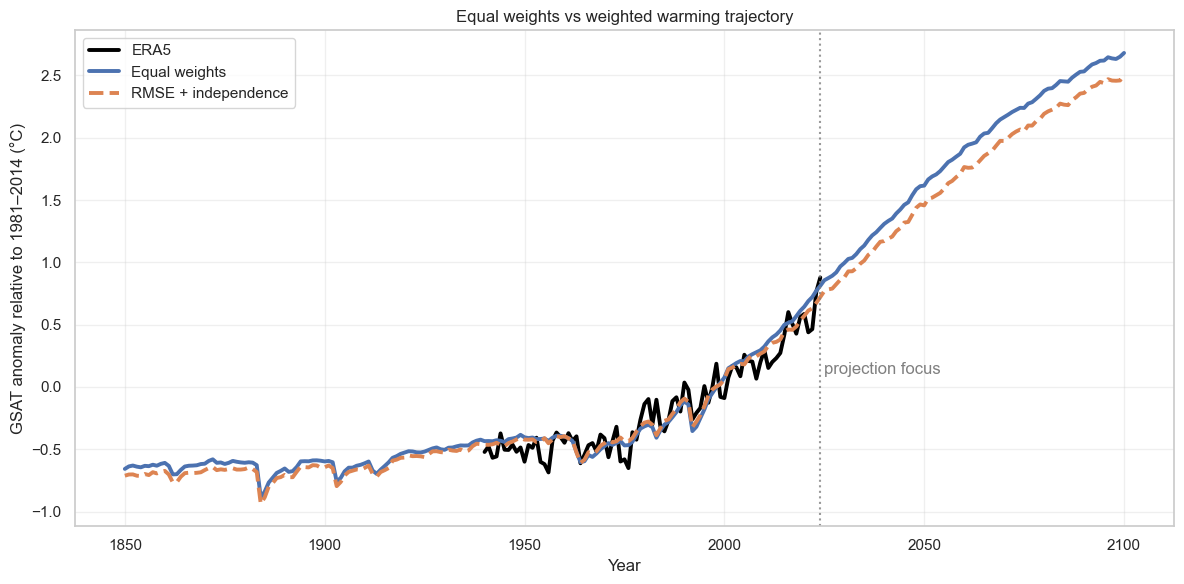

In [40]:
# ============================================================
# 3. Plot full historical + future warming trajectories
# ============================================================

plt.figure(figsize=(12, 6))

# ERA5 observations
plt.plot(
    df_era5["Year"],
    df_era5["Anomaly"],
    color="black",
    linewidth=2.8,
    label="ERA5"
)

# Equal-weight CMIP6 mean
plt.plot(
    traj_df.index,
    traj_df["equal"],
    linewidth=2.8,
    linestyle="-",
    label="Equal weights"
)

# Knutti-weighted CMIP6 mean
plt.plot(
    traj_df.index,
    traj_df["knutti"],
    linewidth=2.8,
    linestyle="--",
    label="RMSE + independence"
)

# Mark the start of the purely future-looking part
plt.axvline(2024, color="gray", linestyle=":", alpha=0.8)
plt.text(2025, 0.1, "projection focus", color="gray")

plt.xlabel("Year")
plt.ylabel("GSAT anomaly relative to 1981–2014 (°C)")
plt.title("Equal weights vs weighted warming trajectory")
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

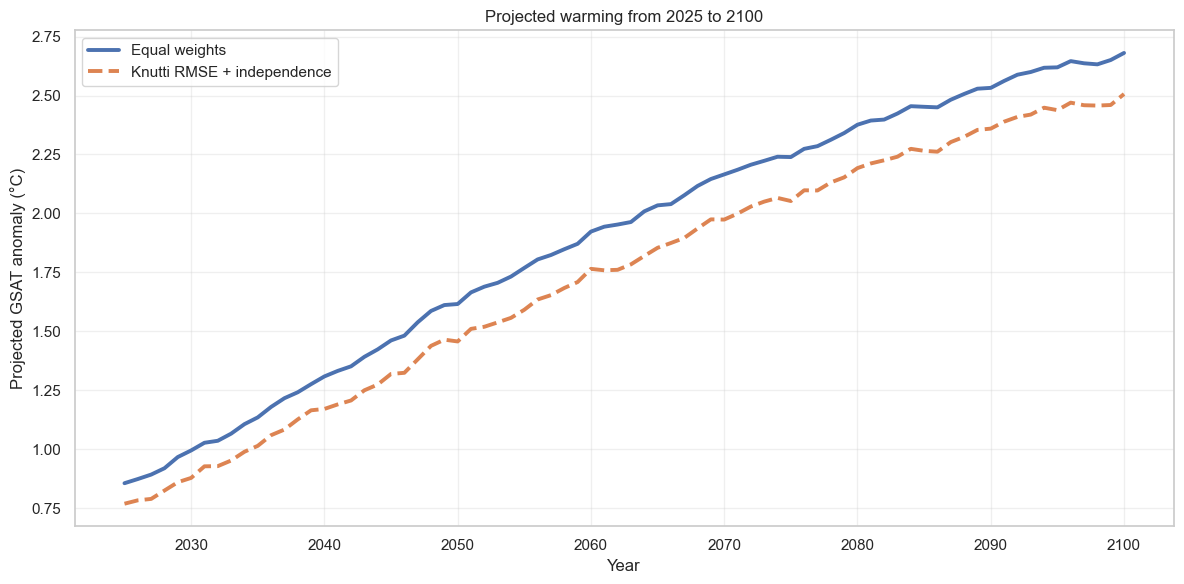

In [41]:
# ============================================================
# 4. Plot future-only warming trajectories
# ============================================================

future_only = traj_df.loc[traj_df.index.to_series().between(2025, 2100)]

plt.figure(figsize=(12, 6))

plt.plot(
    future_only.index,
    future_only["equal"],
    linewidth=2.8,
    linestyle="-",
    label="Equal weights"
)

plt.plot(
    future_only.index,
    future_only["knutti"],
    linewidth=2.8,
    linestyle="--",
    label="Knutti RMSE + independence"
)

plt.xlabel("Year")
plt.ylabel("Projected GSAT anomaly (°C)")
plt.title("Projected warming from 2025 to 2100")
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# 5. Build weighted likely ranges over time
# ============================================================
# For each future year we compute:
# - weighted median
# - weighted 17th percentile
# - weighted 83rd percentile
# This gives a "likely range" comparable to a 66% interval.

future_model_matrix = get_model_matrix(ensemble_mean, 2025, 2100)

def build_weighted_range(model_matrix, weights):
    rows = []

    # Reindex weights so that the model order matches the columns
    w = weights.reindex(model_matrix.columns)

    for year in model_matrix.index:
        values_this_year = model_matrix.loc[year].values

        # Weighted 17th, 50th, and 83rd percentiles
        q17, q50, q83 = weighted_quantile(
            values_this_year,
            [0.17, 0.50, 0.83],
            w.values
        )

        rows.append({
            "Year": year,
            "q17": q17,
            "q50": q50,
            "q83": q83
        })

    return pd.DataFrame(rows).set_index("Year")

equal_range = build_weighted_range(future_model_matrix, equal_weights)
knutti_range = build_weighted_range(future_model_matrix, knutti_weights)

display(equal_range.head())
display(knutti_range.head())

,q17,q50,q83
Year,,,
2025,0.707476,0.816539,1.011977
2026,0.712711,0.815621,1.052240
2027,0.725057,0.839182,1.078157
2028,0.749795,0.872096,1.091169
2029,0.771044,0.932669,1.169517


,q17,q50,q83
Year,,,
2025,0.626648,0.758592,0.878071
2026,0.712155,0.785154,0.873526
2027,0.720708,0.800021,0.867316
2028,0.777734,0.823000,0.905364
2029,0.689215,0.868029,0.970449


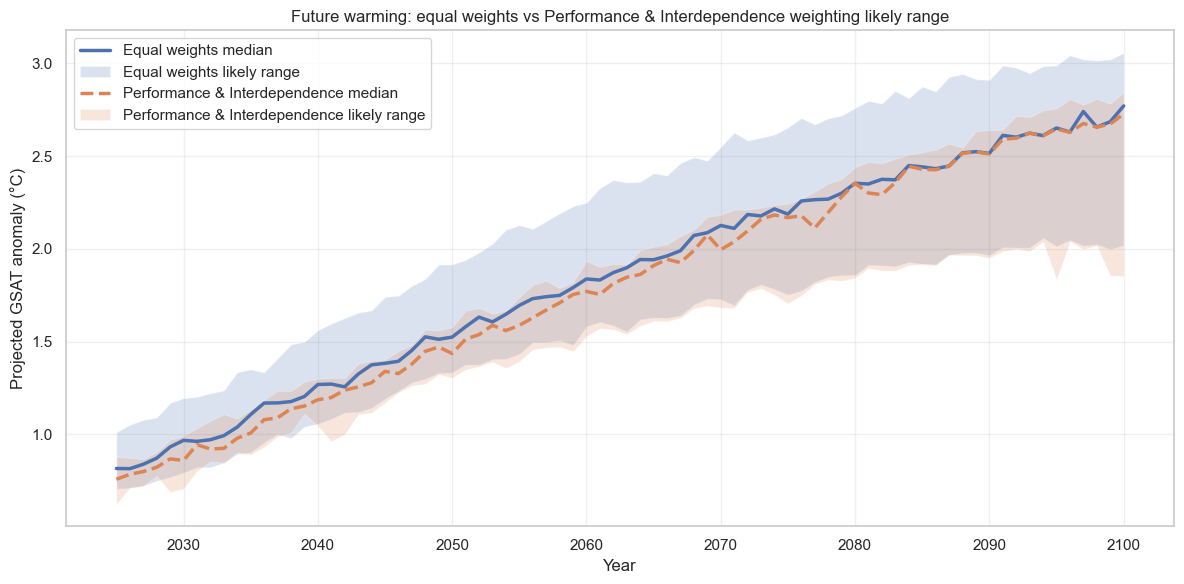

In [45]:
# ============================================================
# 6. Plot future likely ranges over time
# ============================================================

plt.figure(figsize=(12, 6))

# Equal-weight likely range
plt.plot(
    equal_range.index,
    equal_range["q50"],
    linewidth=2.5,
    label="Equal weights median"
)
plt.fill_between(
    equal_range.index,
    equal_range["q17"],
    equal_range["q83"],
    alpha=0.20,
    label="Equal weights likely range"
)

# Knutti-weighted likely range
plt.plot(
    knutti_range.index,
    knutti_range["q50"],
    linewidth=2.5,
    linestyle="--",
    label="Performance & Interdependence median"
)
plt.fill_between(
    knutti_range.index,
    knutti_range["q17"],
    knutti_range["q83"],
    alpha=0.20,
    label="Performance & Interdependence likely range"
)

plt.xlabel("Year")
plt.ylabel("Projected GSAT anomaly (°C)")
plt.title("Future warming: equal weights vs Performance & Interdependence weighting likely range")
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
equal_range

,q17,q50,q83
Year,,,
2025,0.707476,0.816539,1.011977
2026,0.712711,0.815621,1.052240
2027,0.725057,0.839182,1.078157
2028,0.749795,0.872096,1.091169
2029,0.771044,0.932669,1.169517
...,...,...,...
2096,2.048531,2.630699,3.043833
2097,2.018271,2.741145,3.022126
2098,2.024974,2.656930,3.016347


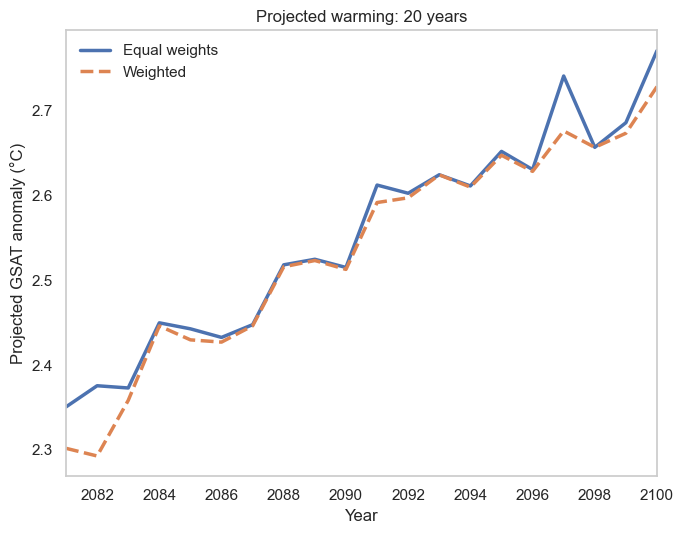

In [46]:
# ============================================================
# 6. Plot future likely ranges over time
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# ===== last 20 years =====
end_year = int(max(equal_range.index.max(), knutti_range.index.max()))
start_year = end_year - 19

equal_20 = equal_range.loc[(equal_range.index >= start_year) & (equal_range.index <= end_year)].copy()
knutti_20 = knutti_range.loc[(knutti_range.index >= start_year) & (knutti_range.index <= end_year)].copy()

# median
equal_median = equal_20["q50"] if "q50" in equal_20.columns else equal.loc[(equal.index >= start_year) & (equal.index <= end_year)]
knutti_median = knutti_20["q50"] if "q50" in knutti_20.columns else knutti.loc[(knutti.index >= start_year) & (knutti.index <= end_year)]

# x ticks: even years only
x_ticks = np.arange(start_year + (start_year % 2), end_year + 1, 2)

plt.figure(figsize=(7, 5.5))

plt.plot(equal_20.index, equal_median, color="#4C72B0", linewidth=2.5, label="Equal weights")
plt.plot(knutti_20.index, knutti_median, color="#DD8452", linestyle="--", linewidth=2.5, label="Weighted")

plt.xlim(start_year, end_year)
plt.xticks(x_ticks)

plt.xlabel("Year")
plt.ylabel("Projected GSAT anomaly (°C)")
plt.title("Projected warming: 20 years")
plt.legend(frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()

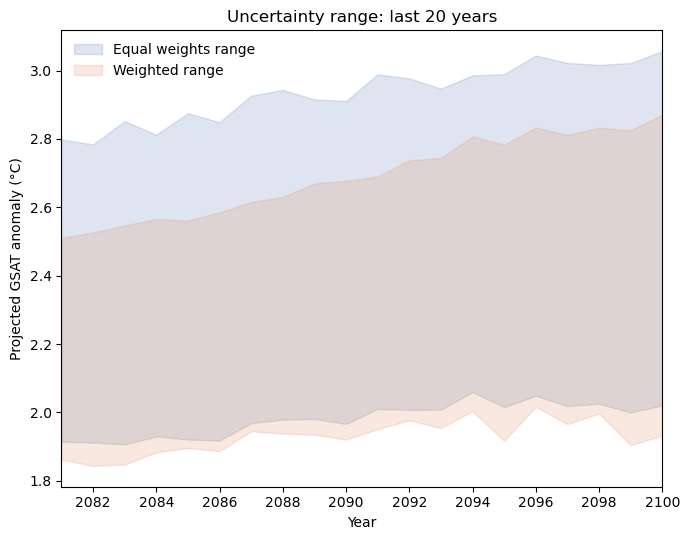

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# ===== last 20 years =====
end_year = int(max(equal_range.index.max(), knutti_range.index.max()))
start_year = end_year - 19

equal_20 = equal_range.loc[(equal_range.index >= start_year) & (equal_range.index <= end_year)].copy()
knutti_20 = knutti_range.loc[(knutti_range.index >= start_year) & (knutti_range.index <= end_year)].copy()

# choose narrower range if available
if ("q30" in equal_20.columns) and ("q70" in equal_20.columns):
    lower_equal, upper_equal = equal_20["q30"], equal_20["q70"]
elif ("q25" in equal_20.columns) and ("q75" in equal_20.columns):
    lower_equal, upper_equal = equal_20["q25"], equal_20["q75"]
else:
    lower_equal, upper_equal = equal_20["q17"], equal_20["q83"]

if ("q30" in knutti_20.columns) and ("q70" in knutti_20.columns):
    lower_knutti, upper_knutti = knutti_20["q30"], knutti_20["q70"]
elif ("q25" in knutti_20.columns) and ("q75" in knutti_20.columns):
    lower_knutti, upper_knutti = knutti_20["q25"], knutti_20["q75"]
else:
    lower_knutti, upper_knutti = knutti_20["q17"], knutti_20["q83"]

# x ticks: even years only
x_ticks = np.arange(start_year + (start_year % 2), end_year + 1, 2)

plt.figure(figsize=(7, 5.5))

plt.fill_between(equal_20.index, lower_equal, upper_equal, color="#4C72B0", alpha=0.18, label="Equal weights range")
plt.fill_between(knutti_20.index, lower_knutti, upper_knutti, color="#DD8452", alpha=0.18, label="Weighted range")

plt.xlim(start_year, end_year)
plt.xticks(x_ticks)

plt.xlabel("Year")
plt.ylabel("Projected GSAT anomaly (°C)")
plt.title("Uncertainty range: last 20 years")
plt.legend(frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 7. Summarize end-of-century warming
# ============================================================

# One end-of-century warming number per model:
# mean anomaly over 2071–2100
future_per_model = (
    ensemble_mean[ensemble_mean["Year"].between(FUTURE_START, FUTURE_END)]
    .groupby("Model")["Anomaly"]
    .mean()
    .sort_index()
)

summary_df = pd.DataFrame([
    summarize_end_of_century(future_per_model, equal_weights, "Equal weights"),
    summarize_end_of_century(future_per_model, knutti_weights, "Knutti RMSE + independence")
])

display(summary_df)

,scheme,mean,q17,q50,q83
0,Equal weights,2.451312,1.927723,2.455399,2.845142
1,Knutti RMSE + independence,2.334852,1.876657,2.430702,2.565241


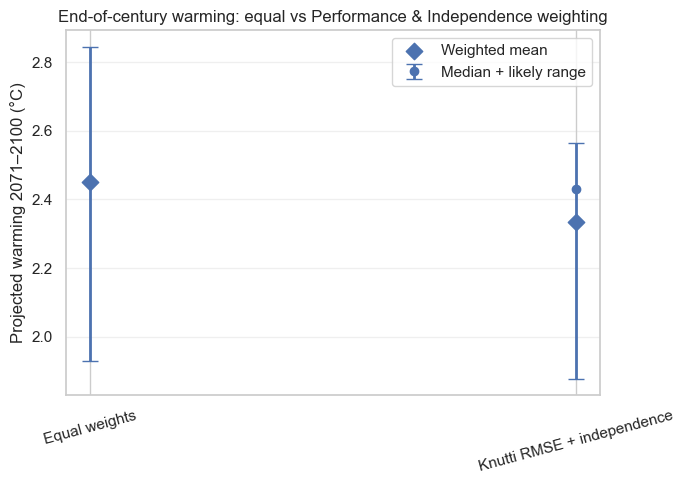

In [28]:
# ============================================================
# 8. Plot end-of-century point estimate + likely range
# ============================================================

plt.figure(figsize=(7, 5))

x = np.arange(len(summary_df))

# Error bars show the likely range around the weighted median
plt.errorbar(
    x,
    summary_df["q50"],
    yerr=[summary_df["q50"] - summary_df["q17"], summary_df["q83"] - summary_df["q50"]],
    fmt="o",
    capsize=6,
    linewidth=2,
    label="Median + likely range"
)

# Diamonds show the weighted mean
plt.scatter(
    x,
    summary_df["mean"],
    marker="D",
    s=70,
    label="Weighted mean"
)

plt.xticks(x, summary_df["scheme"], rotation=15)
plt.ylabel("Projected warming 2071–2100 (°C)")
plt.title("End-of-century warming: equal vs Performance & Independence weighting")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

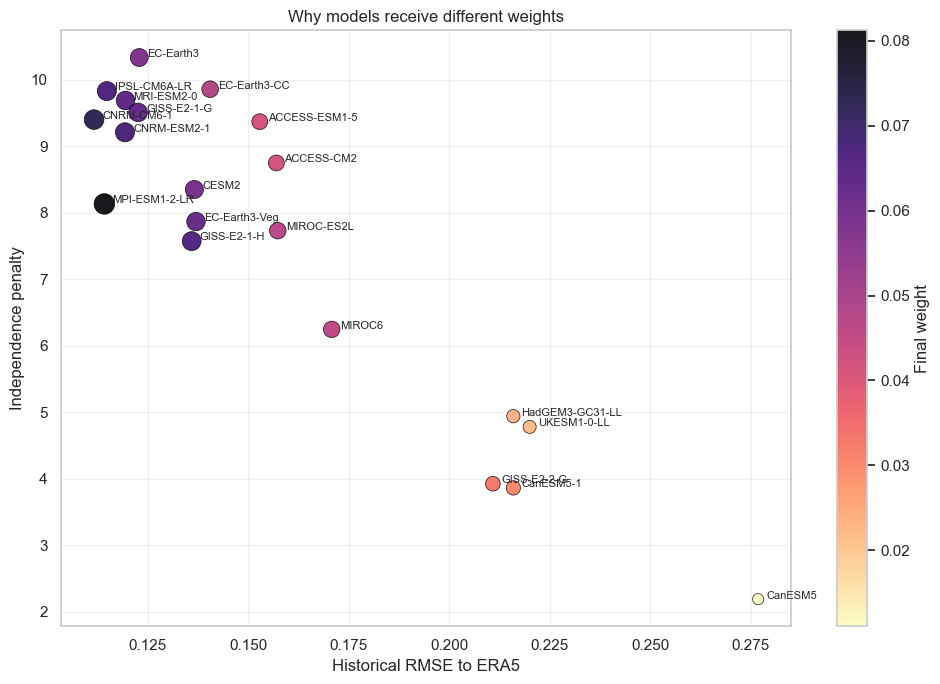

In [34]:
# ============================================================
# Plot why the Knutti weights arise
# ============================================================
# x-axis  = historical RMSE to observations
# y-axis  = independence penalty
# bubble size / color = final Knutti weight
# darker points = larger final weight

plot_df = knutti_diag.reset_index().rename(columns={"index": "Model"})

plt.figure(figsize=(10, 7))

sc = plt.scatter(
    plot_df["RMSE_to_obs"],
    plot_df["independence_penalty"],
    s=2200 * plot_df["weight"] + 40,
    c=plot_df["weight"],
    cmap="magma_r",   # reversed version of magma
    alpha=0.9,
    edgecolors="black",
    linewidths=0.5
)

# Label every model
for _, row in plot_df.iterrows():
    plt.text(
        row["RMSE_to_obs"] + 0.002,
        row["independence_penalty"] + 0.01,
        row["Model"],
        fontsize=8
    )

plt.xlabel("Historical RMSE to ERA5")
plt.ylabel("Independence penalty")
plt.title("Why models receive different weights")
cbar = plt.colorbar(sc)
cbar.set_label("Final weight")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

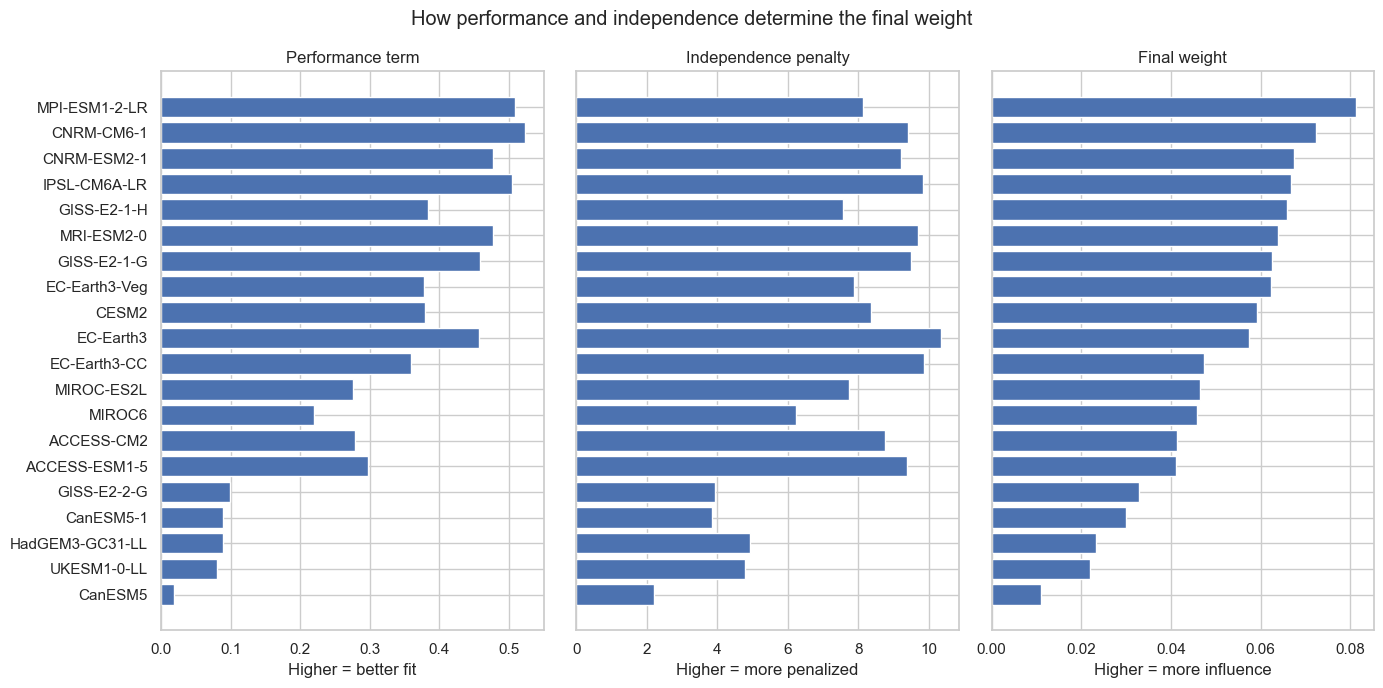

In [31]:
# ============================================================
# Intuitive decomposition of the weighting
# ============================================================

decomp_df = knutti_diag.reset_index().rename(columns={"index": "Model"}).copy()
decomp_df = decomp_df.sort_values("weight", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True)

# 1) Performance term
axes[0].barh(decomp_df["Model"], decomp_df["performance_term"])
axes[0].invert_yaxis()
axes[0].set_title("Performance term")
axes[0].set_xlabel("Higher = better fit")

# 2) Independence penalty
axes[1].barh(decomp_df["Model"], decomp_df["independence_penalty"])
axes[1].set_title("Independence penalty")
axes[1].set_xlabel("Higher = more penalized")

# 3) Final weight
axes[2].barh(decomp_df["Model"], decomp_df["weight"])
axes[2].set_title("Final weight")
axes[2].set_xlabel("Higher = more influence")

plt.suptitle("How performance and independence determine the final weight")
plt.tight_layout()
plt.show()

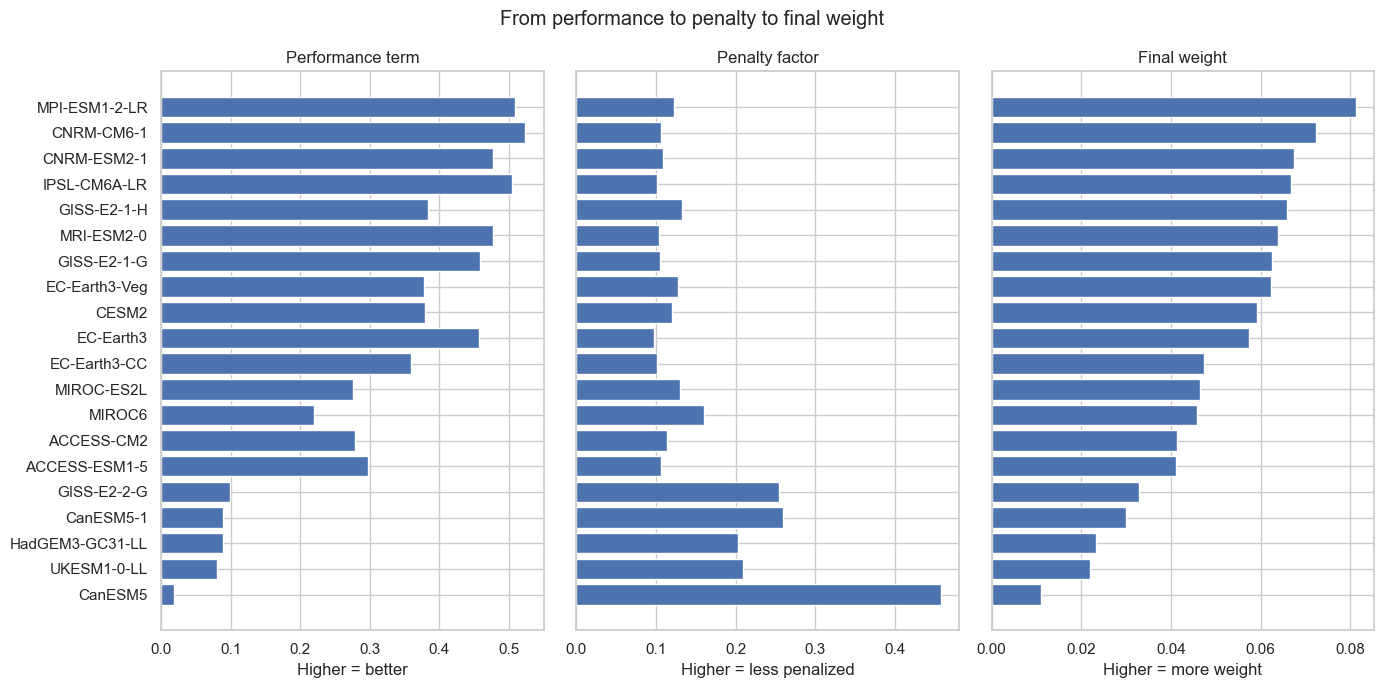

In [32]:
plot_df = knutti_diag.reset_index().rename(columns={"index": "Model"}).copy()
plot_df["penalty_factor"] = 1 / plot_df["independence_penalty"]
plot_df = plot_df.sort_values("weight", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True)

axes[0].barh(plot_df["Model"], plot_df["performance_term"])
axes[0].invert_yaxis()
axes[0].set_title("Performance term")
axes[0].set_xlabel("Higher = better")

axes[1].barh(plot_df["Model"], plot_df["penalty_factor"])
axes[1].set_title("Penalty factor")
axes[1].set_xlabel("Higher = less penalized")

axes[2].barh(plot_df["Model"], plot_df["weight"])
axes[2].set_title("Final weight")
axes[2].set_xlabel("Higher = more weight")

plt.suptitle("From performance to penalty to final weight")
plt.tight_layout()
plt.show()

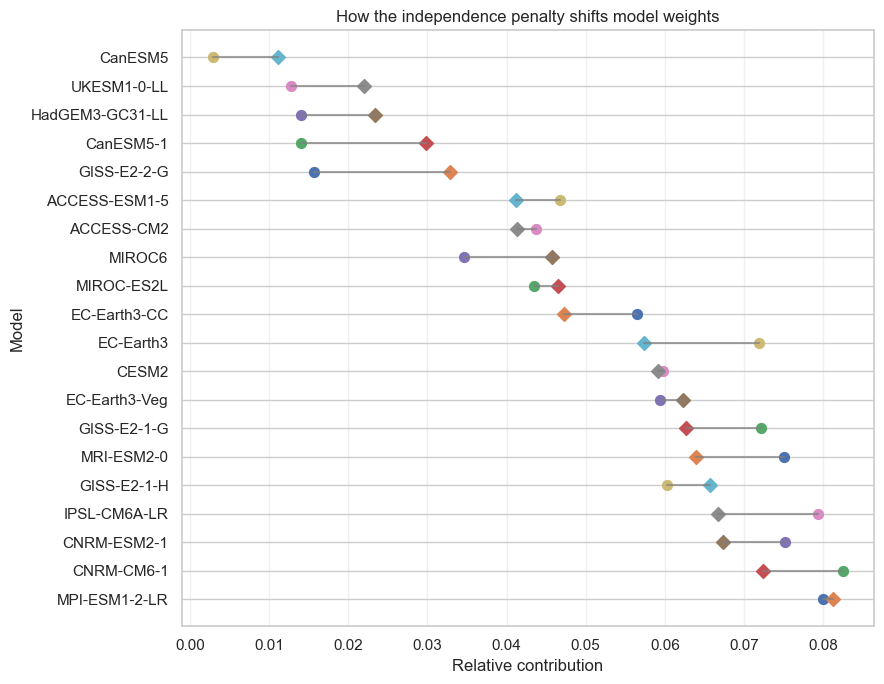

In [33]:
plot_df = knutti_diag.reset_index().rename(columns={"index": "Model"}).copy()
plot_df["penalty_factor"] = 1 / plot_df["independence_penalty"]
plot_df["scaled_performance"] = plot_df["performance_term"] / plot_df["performance_term"].sum()
plot_df = plot_df.sort_values("weight", ascending=False)

plt.figure(figsize=(9, 7))

for _, row in plot_df.iterrows():
    # line from performance-only score to final weight
    plt.plot(
        [row["scaled_performance"], row["weight"]],
        [row["Model"], row["Model"]],
        color="gray",
        alpha=0.7
    )
    plt.scatter(row["scaled_performance"], row["Model"], marker="o", s=50, label=None)
    plt.scatter(row["weight"], row["Model"], marker="D", s=50, label=None)

plt.xlabel("Relative contribution")
plt.ylabel("Model")
plt.title("How the independence penalty shifts model weights")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 9. Plot why the Knutti weights arise
# ============================================================
# x-axis  = historical RMSE to observations
# y-axis  = independence penalty
# bubble size / color = final Knutti weight

plot_df = knutti_diag.reset_index().rename(columns={"index": "Model"})

plt.figure(figsize=(9, 6))

sc = plt.scatter(
    plot_df["RMSE_to_obs"],
    plot_df["independence_penalty"],
    s=2200 * plot_df["weight"] + 40,
    c=plot_df["weight"],
    alpha=0.8
)

# Label the most strongly weighted models
top_models = plot_df.sort_values("weight", ascending=False).head(8)
for _, row in top_models.iterrows():
    plt.text(
        row["RMSE_to_obs"] + 0.002,
        row["independence_penalty"] + 0.01,
        row["Model"],
        fontsize=8
    )

plt.xlabel("Historical RMSE to ERA5")
plt.ylabel("Independence penalty")
plt.title("Why models receive Knutti weights")
cbar = plt.colorbar(sc)
cbar.set_label("Final Knutti weight")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 10. Optional: top Knutti weights
# ============================================================

top_weight_df = (
    knutti_diag["weight"]
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
    .rename(columns={"index": "Model", "weight": "Knutti_weight"})
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_weight_df, x="Model", y="Knutti_weight")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Knutti weight")
plt.title("Top weighted models under RMSE + independence weighting")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Lower RMSE means better historical agreement with ERA5.

perf_df = knutti_diag.reset_index().rename(columns={"index": "Model"})
perf_df = perf_df.sort_values("RMSE_to_obs", ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=perf_df, x="Model", y="RMSE_to_obs")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Historical RMSE to ERA5")
plt.title("Model performance relative to ERA5 (lower is better)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 3. Plot an easier-to-read independence score
# ============================================================

score_df = knutti_diag.reset_index().rename(columns={"index": "Model"}).copy()
score_df["independence_score"] = 1 / score_df["independence_penalty"]
score_df = score_df.sort_values("independence_score", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=score_df, x="Model", y="independence_score")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Independence score")
plt.title("Model independence score (higher means less redundant)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 5. Heatmap of pairwise model similarity distances
# ============================================================
# Smaller values mean models are more similar historically.

plt.figure(figsize=(10, 8))
sns.heatmap(S_ij, cmap="viridis", square=True)
plt.title("Pairwise historical RMSE distance between models")
plt.tight_layout()
plt.show()

In [ ]:
# Start from the diagnostics table produced by the Knutti weighting
perf_df = knutti_diag.reset_index().rename(columns={"index": "Model"}).copy()

# Sort so the best-performing models appear first
perf_df = perf_df.sort_values("RMSE_to_obs", ascending=True)

plt.figure(figsize=(11, 5))
sns.barplot(data=perf_df, x="Model", y="RMSE_to_obs")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Historical RMSE to ERA5")
plt.xlabel("Model")
plt.title("Historical model performance relative to ERA5 (lower is better)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Plot: model performance with color highlighting
# ============================================================

perf_df = knutti_diag.reset_index().rename(columns={"index": "Model"}).copy()
perf_df = perf_df.sort_values("RMSE_to_obs", ascending=True)

# Create simple performance groups
q1 = perf_df["RMSE_to_obs"].quantile(0.33)
q2 = perf_df["RMSE_to_obs"].quantile(0.66)

def classify_perf(x):
    if x <= q1:
        return "good"
    elif x <= q2:
        return "medium"
    else:
        return "weak"

perf_df["performance_group"] = perf_df["RMSE_to_obs"].apply(classify_perf)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=perf_df,
    x="Model",
    y="RMSE_to_obs",
    hue="performance_group",
    dodge=False
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Historical RMSE to ERA5")
plt.xlabel("Model")
plt.title("Historical model performance groups")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 1. Taylor diagram: historical model performance
# ============================================================
# A Taylor diagram summarizes three things at once:
# - correlation with observations
# - standard deviation
# - centered RMSE
#
# Interpretation:
# - angle   -> correlation (closer to x-axis = better)
# - radius  -> standard deviation (closer to obs radius = better)
# - distance to obs point -> centered RMSE (smaller = better)

# ------------------------------------------------------------
# Align the observed and model time series over the calibration period
# ------------------------------------------------------------
common_years = obs_calib.index.intersection(model_calib.index)
obs = obs_calib.loc[common_years]
X = model_calib.loc[common_years]

# Standard deviation of the observations
obs_std = obs.std(ddof=1)

# Compute metrics for each model
taylor_rows = []

for model in X.columns:
    model_series = X[model]

    # Correlation with observations
    corr = np.corrcoef(obs.values, model_series.values)[0, 1]

    # Model standard deviation
    std_model = model_series.std(ddof=1)

    # Centered RMSE
    # remove the mean from both series before computing RMSE
    c_rmse = np.sqrt(np.mean(
        ((model_series - model_series.mean()) - (obs - obs.mean())) ** 2
    ))

    taylor_rows.append({
        "Model": model,
        "corr": corr,
        "std_model": std_model,
        "std_ratio": std_model / obs_std,
        "centered_rmse": c_rmse
    })

taylor_df = pd.DataFrame(taylor_rows)

# Add the final Knutti weight for labeling / emphasis
taylor_df = taylor_df.merge(
    knutti_diag["weight"].rename("knutti_weight"),
    left_on="Model",
    right_index=True,
    how="left"
)

display(taylor_df.head())

In [ ]:
#taylor diagram


# Convert correlation to polar angle
# theta = arccos(correlation)
theta = np.arccos(np.clip(taylor_df["corr"].values, -1, 1))
radius = taylor_df["std_model"].values

# Figure / polar axis
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, polar=True)

# ------------------------------------------------------------
# Configure angular axis to show correlation instead of angle
# ------------------------------------------------------------
corr_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_xticks(np.arccos(corr_ticks[::-1]))
ax.set_xticklabels([f"{c:.2f}" if c < 1 else "1.00" for c in corr_ticks[::-1]])
ax.set_xlabel("Correlation with ERA5", labelpad=20)

# ------------------------------------------------------------
# Radial axis = standard deviation
# ------------------------------------------------------------
max_std = max(radius.max(), obs_std) * 1.35
ax.set_ylim(0, max_std)
ax.set_ylabel("Standard deviation", labelpad=20)

# ------------------------------------------------------------
# Plot the observation reference point
# ------------------------------------------------------------
# In a Taylor diagram, the observation is located at:
# theta = 0   (correlation = 1)
# r     = std(obs)
ax.plot(0, obs_std, "k*", markersize=14, label="ERA5")
ax.text(0.02, obs_std + 0.02, "ERA5", fontsize=10)

# ------------------------------------------------------------
# Plot centered RMSE contours
# Formula:
# cRMSE^2 = r^2 + obs_std^2 - 2*r*obs_std*cos(theta)
# ------------------------------------------------------------
theta_grid = np.linspace(0, np.pi / 2, 300)
r_grid = np.linspace(0, max_std, 300)
Theta, R = np.meshgrid(theta_grid, r_grid)
CRMSE = np.sqrt(R**2 + obs_std**2 - 2 * R * obs_std * np.cos(Theta))

contours = ax.contour(
    Theta,
    R,
    CRMSE,
    levels=6,
    linewidths=0.8,
    alpha=0.7
)
ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")


sc = ax.scatter(
    theta,
    radius,
    s=1400 * taylor_df["knutti_weight"].values + 40,
    c=taylor_df["knutti_weight"].values,
    alpha=0.85
)

# Label the most strongly weighted models
top_models = taylor_df.sort_values("knutti_weight", ascending=False).head(8)
for _, row in top_models.iterrows():
    ax.text(
        np.arccos(np.clip(row["corr"], -1, 1)),
        row["std_model"] + 0.02,
        row["Model"],
        fontsize=8
    )

cbar = plt.colorbar(sc, pad=0.12)
cbar.set_label("Final Knutti weight")

plt.title("Taylor diagram of historical model performance (1940–2024)")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4. Optional: pairwise model similarity heatmap
# ============================================================
# Smaller values = models are more similar historically

plt.figure(figsize=(10, 8))
sns.heatmap(S_ij, cmap="viridis", square=True)
plt.title("Pairwise historical RMSE distance between models")
plt.tight_layout()
plt.show()